<a href="https://colab.research.google.com/github/cdmafAdi/computer_vision_lecture_notes/blob/main/6_handling_overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handling overfitting with
**1. Dropout**
**2. Regularization**
**3. early stopping**
**4. Battchnormalization**


In [ ]:
import tensorflow as tf

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print(data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
/root/.keras/datasets/flower_photos


In [ ]:
image_height = 224
image_width = 224
image_channel = 3

CLASS_NAMES = ["daisy", "dandelion", "roses", "sunflowers", "tulips"]

**validation dataset**

In [ ]:
o_dir = '/root/.keras/datasets/flower_photos/flower_photos'

train_ds =  tf.keras.utils.image_dataset_from_directory(
    o_dir,
    validation_split = 0.2,
    subset = 'training',
    image_size=(224,224),
    batch_size=32,
    seed = 123
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    o_dir,
    validation_split = 0.2,
    subset='validation',
    seed = 123,
    image_size=(224,224),
    batch_size=32
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


**batch wise output label of data**

In [ ]:
# for image_batch, labels_batch in train_ds:
#   print("image batch shape: ", image_batch.shape)
#   print("labels batch shape: ", labels_batch.shape)
#   print("labels: ", label_batch.numpy())

In [ ]:
from tensorflow import keras



regularizer = keras.regularizers.l1_l2(0,0.1)

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(image_height, image_width,image_channel)),
    keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),


    keras.layers.Dense(len(CLASS_NAMES), activation="softmax", kernel_regularizer=regularizer),
    keras.layers.BatchNormalization()
])

model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

In [ ]:
history2 = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=10,
      callbacks=[
          tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,monitor='val_loss')
      ]
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 105ms/step - accuracy: 0.3140 - loss: 26.7822 - val_accuracy: 0.2084 - val_loss: 31.1006
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.2953 - loss: 34.0771 - val_accuracy: 0.2071 - val_loss: 38.3350
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.3065 - loss: 48.6548 - val_accuracy: 0.2752 - val_loss: 71.6519
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.2987 - loss: 64.3301 - val_accuracy: 0.2875 - val_loss: 57.7046
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.3161 - loss: 50.3098 - val_accuracy: 0.2684 - val_loss: 37.3886
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.3069 - loss: 39.4071 - val_accuracy: 0.2534 - val_loss: 49.9353


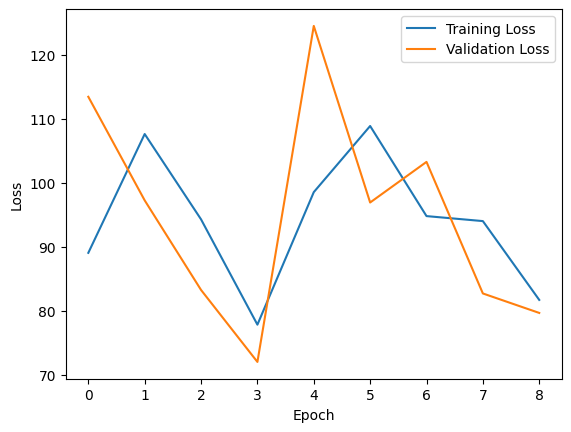

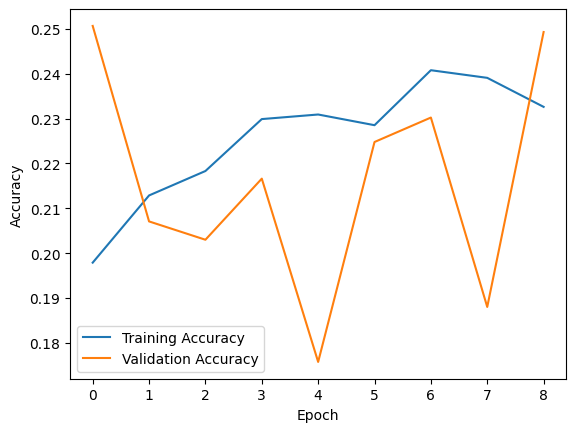

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


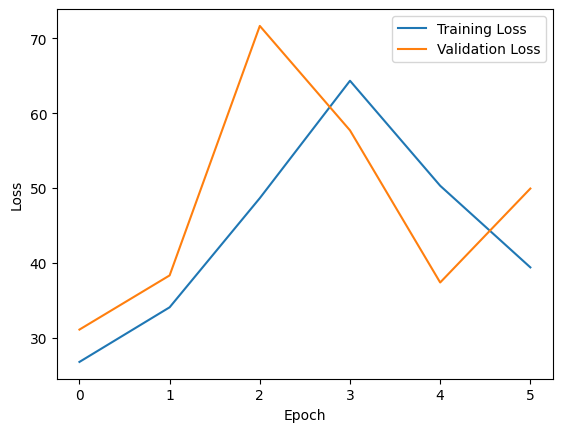

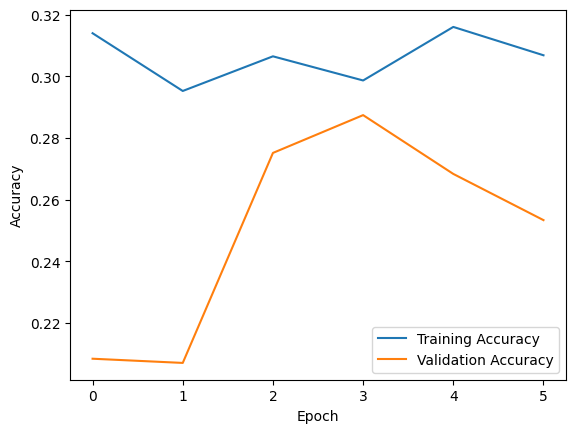

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history2.history["loss"], label="Training Loss")
plt.plot(history2.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history2.history["accuracy"], label="Training Accuracy")
plt.plot(history2.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()